# Laboratorio 5 — Clasificación con Árbol de Decisión
**Curso:** Minería de Datos (EIN132A25)
**Dataset:** Pokémon (Gen 1–6)

## Objetivos
- Preparar el dataset Pokémon para clasificación
- Entrenar un **árbol de decisión** para predecir si un Pokémon es **Legendario**
- Hacer predicciones y evaluar el modelo
- Visualizar el árbol e interpretar la importancia de features

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

url = 'pokemon.csv'
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
df.head()

Shape: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## 1. Preparar el dataset

**Target:** `Legendary` (True/False) — ¿es un Pokémon legendario?

**Features:** estadísticas de combate + generación + tipo principal

In [4]:
!pip install scikit-learn --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet
!pip install pandas --quiet
!pip install numpy --quiet
!pip install plotly --quiet

In [3]:
from sklearn.preprocessing import LabelEncoder

# Imputar Type 2
df["Type 2"] = df["Type 2"].fillna("None")

# Encoding de Type 1
le = LabelEncoder()
df["Type1_enc"] = le.fit_transform(df["Type 1"])

# Target: Legendary → int
df["Legendary_int"] = df["Legendary"].astype(int)

features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation", "Type1_enc"]

X = df[features]
y = df["Legendary_int"]

print(f"Shape de X: {X.shape}")
print(f"\nDistribución del target:")
print(y.value_counts().rename({0: 'No Legendario', 1: 'Legendario'}))
print(f"\nClase minoritaria: {y.mean()*100:.1f}% legendarios")

Shape de X: (800, 8)

Distribución del target:
Legendary_int
No Legendario    735
Legendario        65
Name: count, dtype: int64

Clase minoritaria: 8.1% legendarios


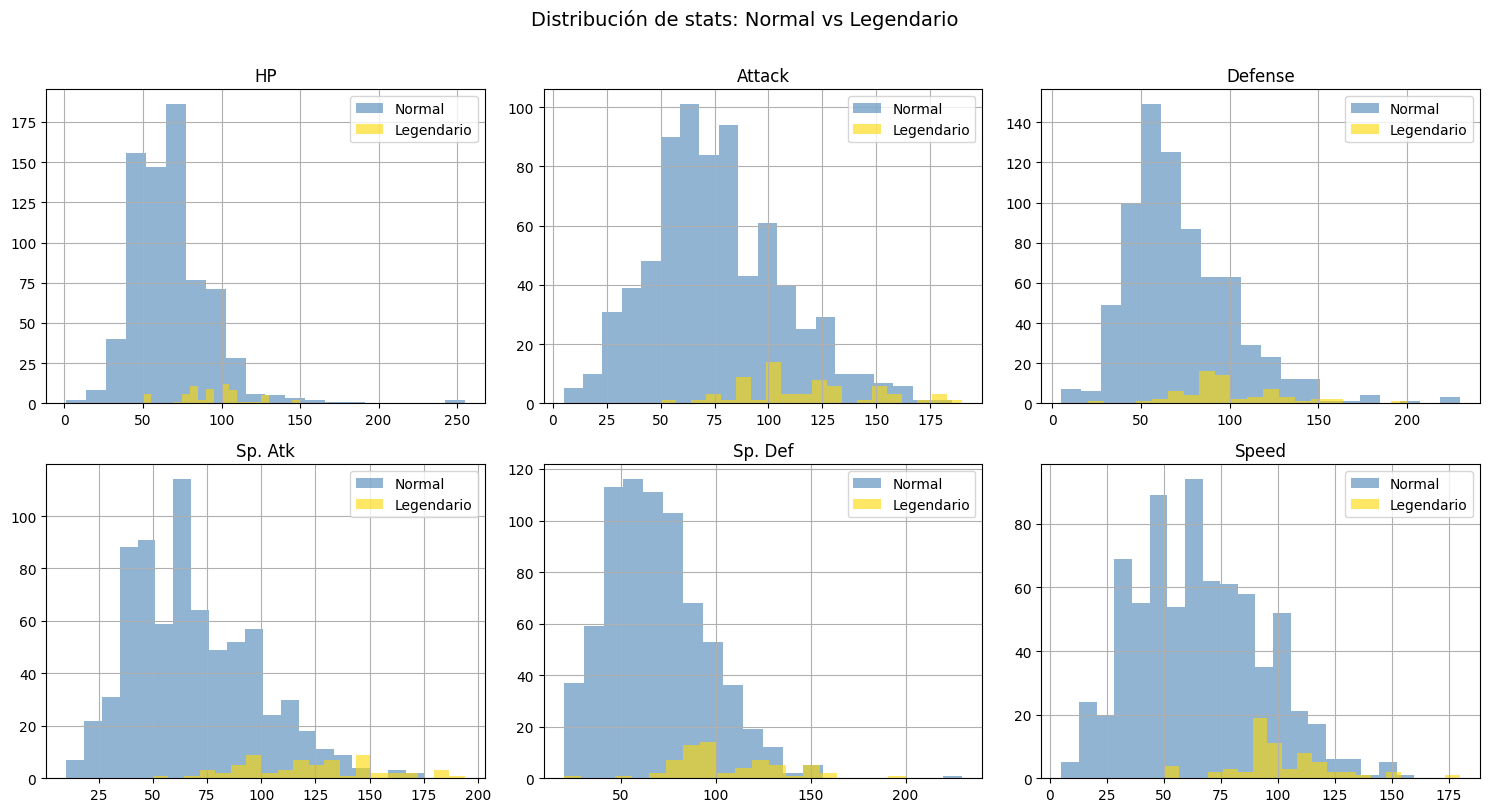

In [5]:
# Visualizar distribución de stats por clase
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
stat_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

for i, col in enumerate(stat_cols):
    ax = axes[i // 3][i % 3]
    df[df["Legendary"] == False][col].hist(bins=20, alpha=0.6, color="steelblue", label="Normal", ax=ax)
    df[df["Legendary"] == True][col].hist(bins=20, alpha=0.6, color="gold", label="Legendario", ax=ax)
    ax.set_title(col)
    ax.legend()

plt.suptitle("Distribución de stats: Normal vs Legendario", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Separar en Train y Test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"\nLegendarios en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Legendarios en test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train: 640 muestras
Test:  160 muestras

Legendarios en train: 52 (8.1%)
Legendarios en test:  13 (8.1%)


## 3. Entrenar el árbol de decisión

In [7]:
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)
print("Modelo entrenado.")
print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de hojas: {modelo.get_n_leaves()}")

Modelo entrenado.
Profundidad del árbol: 4
Número de hojas: 12


## 4. Predicciones y evaluación

In [9]:
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {accuracy:.4f} ({accuracy*100:.1f}%)")

Accuracy en test: 0.9250 (92.5%)


In [10]:
print(classification_report(y_test, y_pred, target_names=["No Legendario", "Legendario"]))

               precision    recall  f1-score   support

No Legendario       0.94      0.99      0.96       147
   Legendario       0.60      0.23      0.33        13

     accuracy                           0.93       160
    macro avg       0.77      0.61      0.65       160
 weighted avg       0.91      0.93      0.91       160



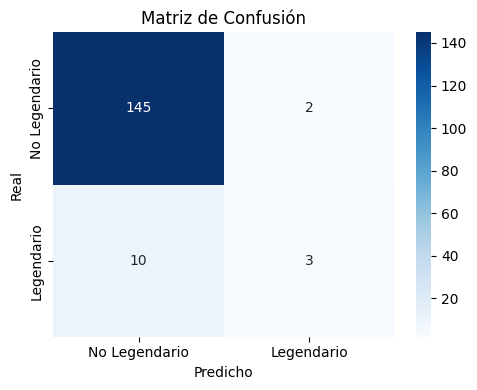

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Legendario", "Legendario"],
            yticklabels=["No Legendario", "Legendario"]
            )
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

In [13]:
acc_train = accuracy_score(y_train, modelo.predict(X_train))
acc_test  = accuracy_score(y_test, y_pred)
print(f"Accuracy TRAIN: {acc_train:.4f}")
print(f"Accuracy TEST:  {acc_test:.4f}")

Accuracy TRAIN: 0.9609
Accuracy TEST:  0.9250


## 5. Visualizar el árbol

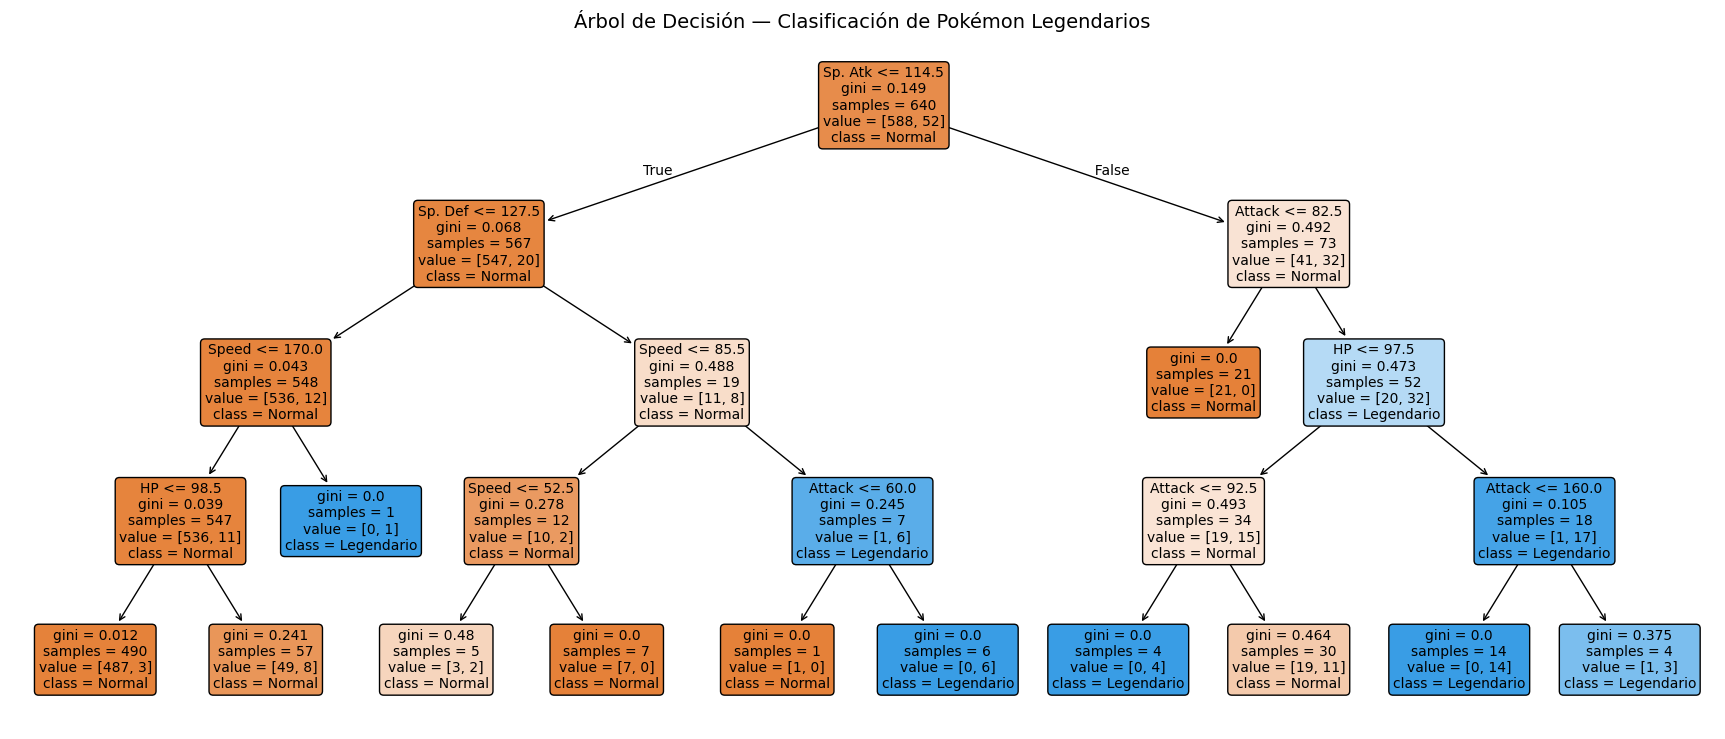

In [14]:
plt.figure(figsize=(22, 9))
plot_tree(modelo, feature_names=features,
          class_names=["Normal", "Legendario"],
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión — Clasificación de Pokémon Legendarios", fontsize=14)
plt.show()

## 6. Importancia de features

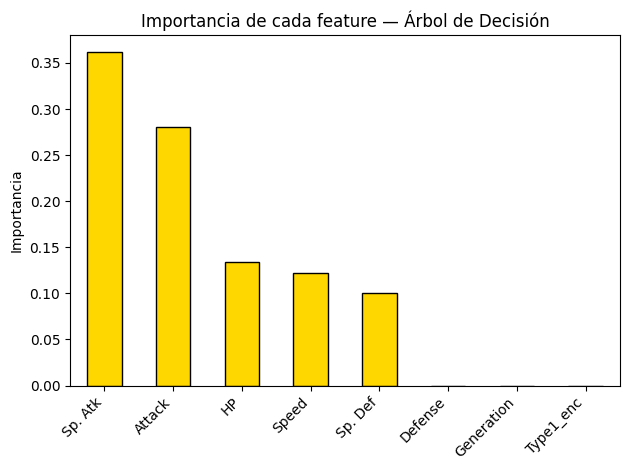

Sp. Atk       0.362346
Attack        0.280425
HP            0.134515
Speed         0.121825
Sp. Def       0.100889
Defense       0.000000
Generation    0.000000
Type1_enc     0.000000
dtype: float64


In [15]:
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)
importancias.plot(kind="bar", color="gold", edgecolor="black")
plt.title("Importancia de cada feature — Árbol de Decisión")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(importancias)

## Ejercicios

### Ejercicio 1 — Comparar max_depth=1 vs max_depth=10

In [16]:
for depth in [1, 10]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f"max_depth={depth:2d}: Train={tr:.4f}, Test={te:.4f}")

max_depth= 1: Train=0.9187, Test=0.9187
max_depth=10: Train=1.0000, Test=0.9437


### Ejercicio 2 — Agregar Total como feature

In [17]:
features2 = features + ["Total"]
X2 = df[features2]
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42, stratify=y)
m2 = DecisionTreeClassifier(max_depth=4, random_state=42)
m2.fit(X2_train, y_train)
print(f"Accuracy SIN Total:  {accuracy_score(y_test, modelo.predict(X_test)):.4f}")
print(f"Accuracy CON Total:  {accuracy_score(y_test, m2.predict(X2_test)):.4f}")

Accuracy SIN Total:  0.9250
Accuracy CON Total:  0.9437


### Desafío — Curva de overfitting

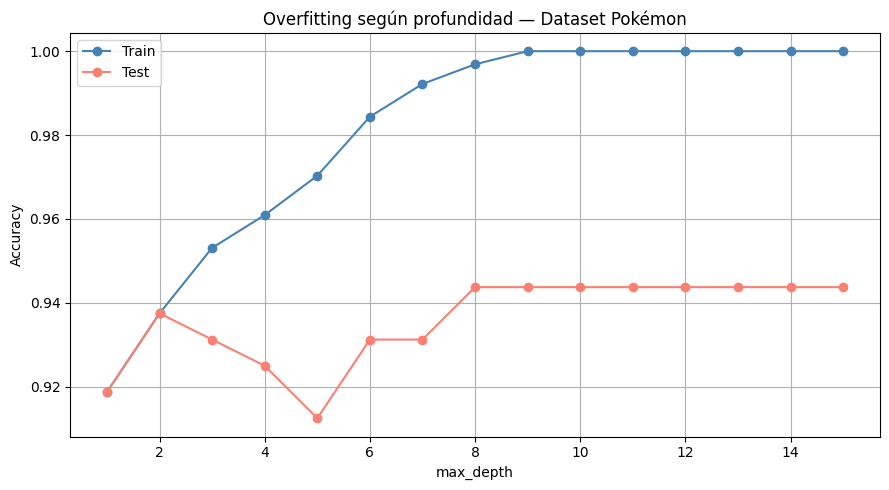

In [18]:
depths = range(1, 16)
train_scores = []
test_scores  = []

for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, label="Train", marker="o", color="steelblue")
plt.plot(depths, test_scores, label="Test", marker="o", color="salmon")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting según profundidad — Dataset Pokémon")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()